In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
print("Ready!")

Ready!


In [2]:
# Load data
aapl = pd.read_csv('../data/raw/AAPL.csv')

# Clean column names
aapl.columns = aapl.columns.str.lower()

# Convert date
aapl['date'] = pd.to_datetime(aapl['date'])

# Sort by date
aapl = aapl.sort_values('date').reset_index(drop=True)

# Check
print(f"Shape: {aapl.shape}")
print(f"Date range: {aapl['date'].min()} to {aapl['date'].max()}")
aapl.head()

Shape: (3774, 6)
Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


,date,close,high,low,open,volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
# Calculate 20-day and 50-day SMA using 'close' column
aapl['sma_20'] = aapl['close'].rolling(window=20).mean()
aapl['sma_50'] = aapl['close'].rolling(window=50).mean()

# Check results
aapl[['date', 'close', 'sma_20', 'sma_50']].tail(10)

,date,close,sma_20,sma_50
3764,2023-12-15,195.721619,190.723320,181.953393
3765,2023-12-18,194.057343,191.030421,182.322577
3766,2023-12-19,195.097504,191.302353,182.682884
3767,2023-12-20,193.007248,191.509893,183.013258
3768,2023-12-21,192.858643,191.676816,183.312761
3769,2023-12-22,191.788757,191.856618,183.572859
3770,2023-12-26,191.243912,192.018094,183.858864
3771,2023-12-27,191.342972,192.154308,184.149424
3772,2023-12-28,191.768951,192.362839,184.479567
3773,2023-12-29,190.728775,192.490633,184.814828


In [4]:
# Check column names
print(aapl.columns.tolist())

['date', 'close', 'high', 'low', 'open', 'volume']


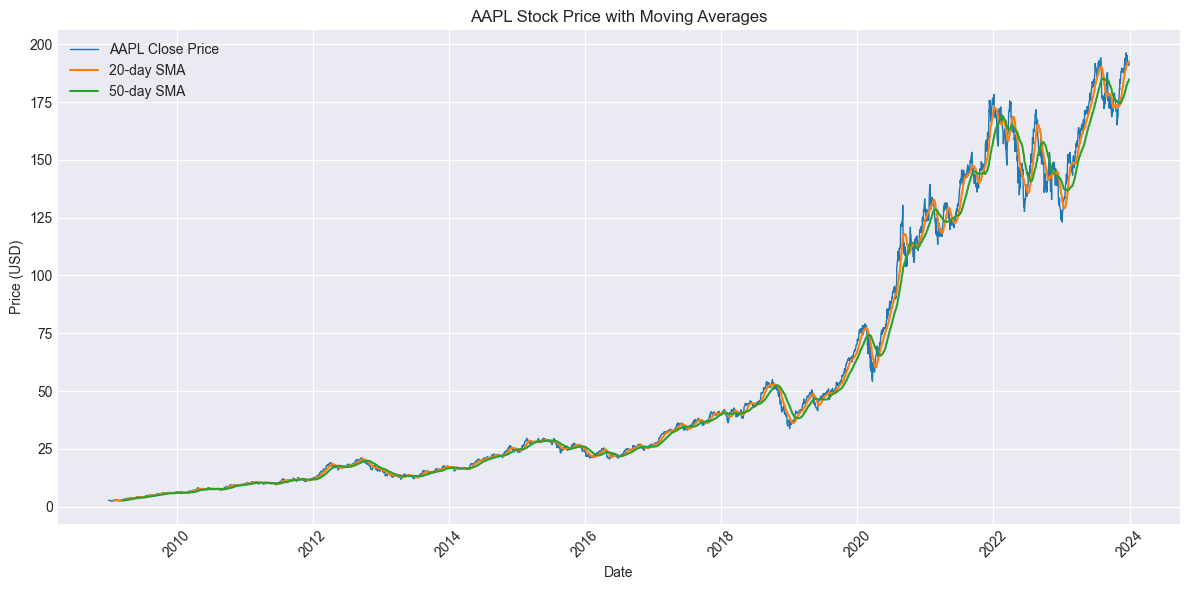

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(aapl['date'], aapl['close'], label='AAPL Close Price', linewidth=1)
plt.plot(aapl['date'], aapl['sma_20'], label='20-day SMA', linewidth=1.5)
plt.plot(aapl['date'], aapl['sma_50'], label='50-day SMA', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('AAPL Stock Price with Moving Averages')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Calculate RSI (Relative Strength Index)
delta = aapl['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
aapl['rsi'] = 100 - (100 / (1 + rs))

# Calculate MACD
ema_12 = aapl['close'].ewm(span=12, adjust=False).mean()
ema_26 = aapl['close'].ewm(span=26, adjust=False).mean()
aapl['macd'] = ema_12 - ema_26
aapl['macd_signal'] = aapl['macd'].ewm(span=9, adjust=False).mean()
aapl['macd_histogram'] = aapl['macd'] - aapl['macd_signal']

print("RSI and MACD calculated!")

RSI and MACD calculated!


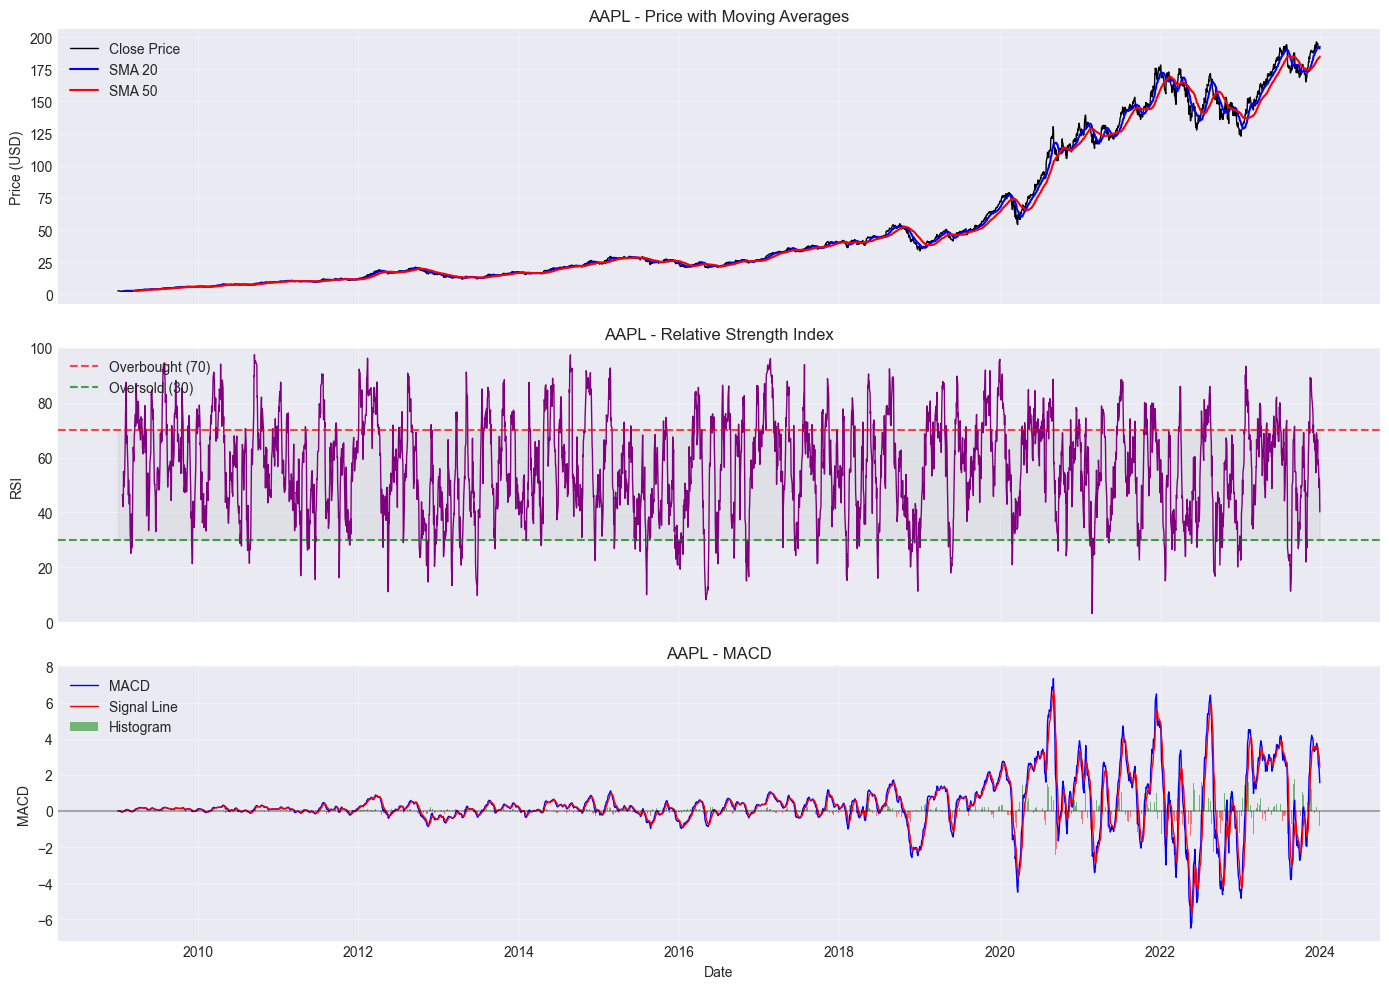

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Price with Moving Averages
axes[0].plot(aapl['date'], aapl['close'], label='Close Price', linewidth=1, color='black')
axes[0].plot(aapl['date'], aapl['sma_20'], label='SMA 20', linewidth=1.5, color='blue')
axes[0].plot(aapl['date'], aapl['sma_50'], label='SMA 50', linewidth=1.5, color='red')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('AAPL - Price with Moving Averages')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: RSI
axes[1].plot(aapl['date'], aapl['rsi'], linewidth=1, color='purple')
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(aapl['date'], 30, 70, alpha=0.1, color='gray')
axes[1].set_ylabel('RSI')
axes[1].set_title('AAPL - Relative Strength Index')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot 3: MACD
axes[2].plot(aapl['date'], aapl['macd'], label='MACD', linewidth=1, color='blue')
axes[2].plot(aapl['date'], aapl['macd_signal'], label='Signal Line', linewidth=1, color='red')
colors = ['green' if val >= 0 else 'red' for val in aapl['macd_histogram']]
axes[2].bar(aapl['date'], aapl['macd_histogram'], color=colors, alpha=0.5, label='Histogram')
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('MACD')
axes[2].set_title('AAPL - MACD')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
latest_rsi = aapl['rsi'].iloc[-1]
print(f"AAPL Latest RSI: {latest_rsi:.1f}")

if latest_rsi > 70:
    print("Signal: OVERBOUGHT - Consider SELLING")
elif latest_rsi < 30:
    print("Signal: OVERSOLD - Consider BUYING")
else:
    print("Signal: NEUTRAL - No strong signal")

AAPL Latest RSI: 40.2
Signal: NEUTRAL - No strong signal


In [10]:
aapl['daily_return'] = aapl['close'].pct_change() * 100
aapl[['date', 'close', 'daily_return']].tail(10)

,date,close,daily_return
3764,2023-12-15,195.721619,-0.272589
3765,2023-12-18,194.057343,-0.850328
3766,2023-12-19,195.097504,0.536007
3767,2023-12-20,193.007248,-1.071390
3768,2023-12-21,192.858643,-0.076995
3769,2023-12-22,191.788757,-0.554751
3770,2023-12-26,191.243912,-0.284086
3771,2023-12-27,191.342972,0.051798
3772,2023-12-28,191.768951,0.222626
3773,2023-12-29,190.728775,-0.542411


In [12]:
# Load all stocks
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
all_stocks = {}

for ticker in tickers:
    df = pd.read_csv(f'../data/raw/{ticker}.csv')
    df.columns = df.columns.str.lower()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    # Calculate indicators for each
    df['sma_20'] = df['close'].rolling(window=20).mean()
    df['sma_50'] = df['close'].rolling(window=50).mean()
    
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    ema_12 = df['close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema_12 - ema_26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_histogram'] = df['macd'] - df['macd_signal']
    
    df['daily_return'] = df['close'].pct_change() * 100
    
    all_stocks[ticker] = df
    print(f"- {ticker}: {len(df)} rows, RSI latest = {df['rsi'].iloc[-1]:.1f}")

print("\nAll 5 stocks loaded and indicators calculated!")

- AAPL: 3774 rows, RSI latest = 40.2
- AMZN: 3774 rows, RSI latest = 62.4
- GOOG: 3774 rows, RSI latest = 63.7
- META: 2923 rows, RSI latest = 70.6
- NVDA: 3774 rows, RSI latest = 62.6

All 5 stocks loaded and indicators calculated!


In [13]:
print("=" * 50)
print("CURRENT RSI STATUS FOR ALL STOCKS")
print("=" * 50)

for ticker in tickers:
    rsi_val = all_stocks[ticker]['rsi'].iloc[-1]
    if rsi_val > 70:
        signal = "🔴 OVERBOUGHT - SELL"
    elif rsi_val < 30:
        signal = "🟢 OVERSOLD - BUY"
    else:
        signal = "⚪ NEUTRAL"
    print(f"{ticker}: RSI = {rsi_val:.1f} -> {signal}")

CURRENT RSI STATUS FOR ALL STOCKS
AAPL: RSI = 40.2 -> ⚪ NEUTRAL
AMZN: RSI = 62.4 -> ⚪ NEUTRAL
GOOG: RSI = 63.7 -> ⚪ NEUTRAL
META: RSI = 70.6 -> 🔴 OVERBOUGHT - SELL
NVDA: RSI = 62.6 -> ⚪ NEUTRAL


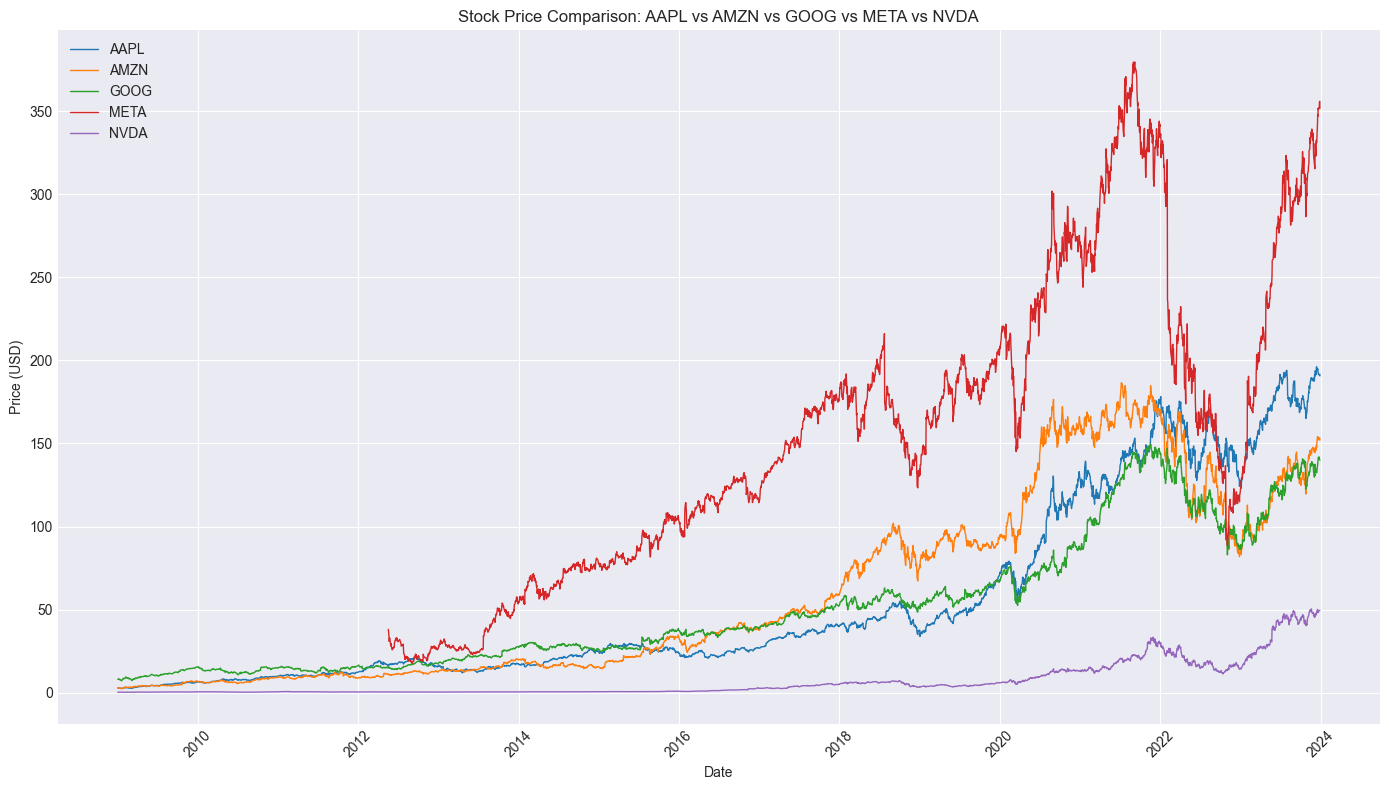

In [14]:
plt.figure(figsize=(14, 8))
for ticker in tickers:
    plt.plot(all_stocks[ticker]['date'], all_stocks[ticker]['close'], label=ticker, linewidth=1)

plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Stock Price Comparison: AAPL vs AMZN vs GOOG vs META vs NVDA')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()